In [1]:
from nilearn import datasets
import nibabel as nib

stat_img = datasets.load_sample_motor_activation_image()
img = nib.load(stat_img)

In [2]:
img.shape

(53, 63, 46)

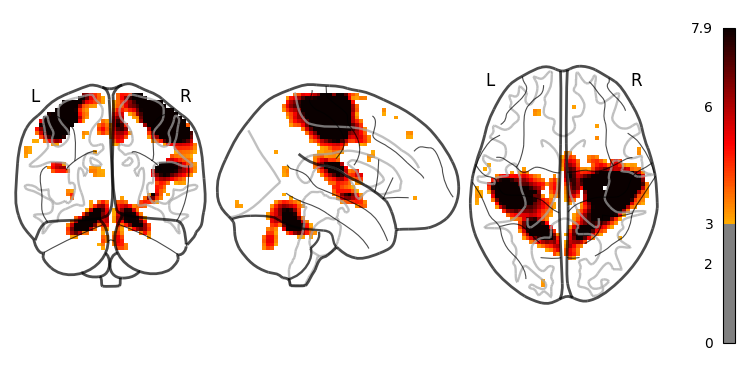

In [3]:
from nilearn import plotting

plotting.plot_glass_brain(stat_img, threshold=3)

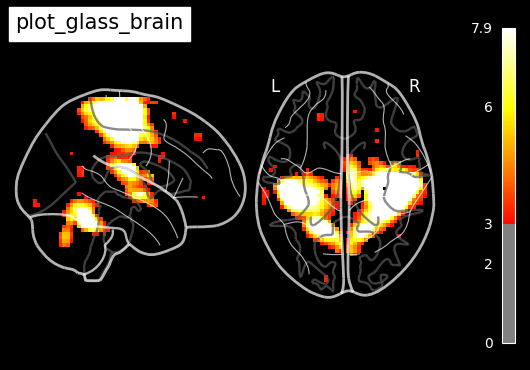

In [4]:
plotting.plot_glass_brain(
    stat_img,
    title="plot_glass_brain",
    black_bg=True,
    display_mode="xz",
    threshold=3,
)

In [5]:
from nilearn.maskers import NiftiMasker

In [ ]:
from nilearn import datasets

atlas = datasets.fetch_atlas_msdl()
# Loading atlas image stored in 'maps'
atlas_filename = atlas["maps"]
# Loading atlas data stored in 'labels'
labels = atlas["labels"]

# Loading the functional datasets
data = datasets.fetch_development_fmri(n_subjects=1)

# print basic information on the dataset
print(f"First subject functional nifti images (4D) are at: {data.func[0]}")

[fetch_atlas_msdl] Dataset found in /home/dani2442/nilearn_data/msdl_atlas
[fetch_development_fmri] Dataset found in /home/dani2442/nilearn_data/development_fmri
[fetch_development_fmri] Dataset found in /home/dani2442/nilearn_data/development_fmri/development_fmri
[fetch_development_fmri] Dataset found in /home/dani2442/nilearn_data/development_fmri/development_fmri
First subject functional nifti images (4D) are at: /home/dani2442/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz


In [7]:
img = nib.load(data.func[0])
img.shape

(50, 59, 50, 168)

In [8]:
from nilearn.maskers import NiftiMapsMasker

masker = NiftiMapsMasker(
    maps_img=atlas_filename,
    standardize="zscore_sample",
    standardize_confounds=True,
    memory="nilearn_cache",
    verbose=5,
)

time_series = masker.fit_transform(data.func[0], confounds=data.confounds)

[NiftiMapsMasker.wrapped] loading regions from /home/dani2442/nilearn_data/msdl_atlas/MSDL_rois/msdl_rois.nii
[NiftiMapsMasker.wrapped] Resampling maps...
[Memory]0.0s, 0.0min    : Loading resample_img...
________________________________________resample_img cache loaded - 0.1s, 0.0min


/home/dani2442/Projects/neuroscience/.venv/lib/python3.11/site-packages/sklearn/utils/_set_output.py:316: UserWarning: memory_level is currently set to 0 but a Memory object has been provided. Setting memory_level to 1.
  data_to_wrap = f(self, X, *args, **kwargs)


[Memory]0.7s, 0.0min    : Loading filter_and_extract...
__________________________________filter_and_extract cache loaded - 0.0s, 0.0min


In [9]:
from sklearn.covariance import GraphicalLassoCV

estimator = GraphicalLassoCV()
estimator.fit(time_series)

,alphas,4
,n_refinements,4
,cv,None
,tol,0.0001
,enet_tol,0.0001
,max_iter,100
,mode,'cd'
,n_jobs,None
,verbose,False
,eps,np.float64(2....049250313e-16)
,assume_centered,False


In [10]:
time_series.shape

(168, 39)

In [11]:
estimator.covariance_.shape

(39, 39)

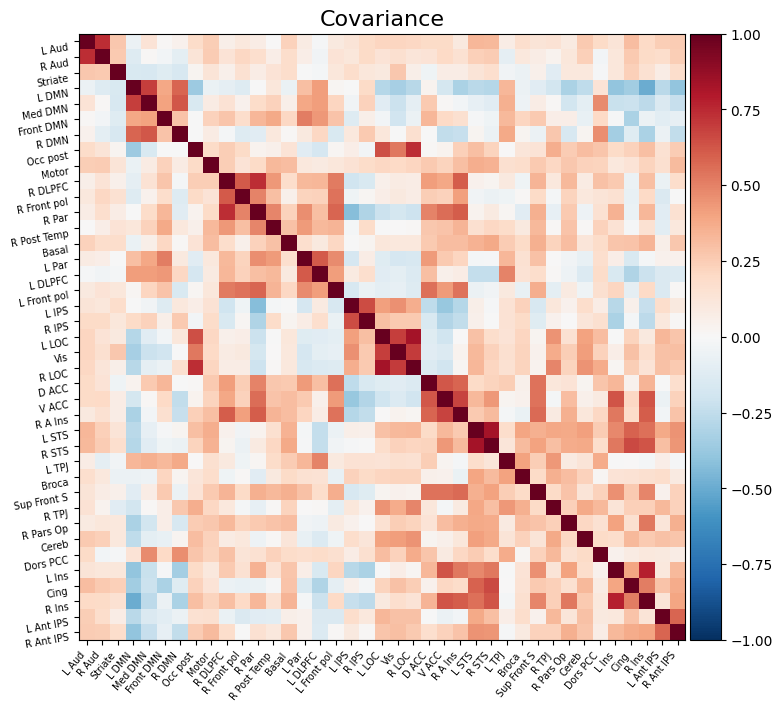

In [12]:
from nilearn import plotting

# Display the covariance

# The covariance can be found at estimator.covariance_
plotting.plot_matrix(
    estimator.covariance_,
    labels=labels,
    figure=(9, 7),
    vmax=1,
    vmin=-1,
    title="Covariance",
)

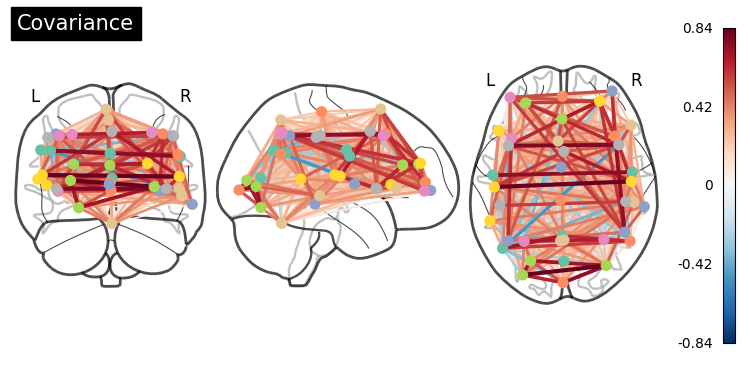

In [13]:
coords = atlas.region_coords

plotting.plot_connectome(estimator.covariance_, coords, title="Covariance")